# Random Forest na Classificação do Desempenho dos Alunos

# Seção 1: Importação do Dataset e Dataset Usado

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

In [ ]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_SEXO','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO']

df = pd.read_parquet("enem_parquet", columns = colunas)

In [ ]:
df

,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,...,TP_PRESENCA_CN,TP_PRESENCA_MT,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_ESCOLA,TP_ST_CONCLUSAO,IN_TREINEIRO,NU_ANO
0,B,B,A,A,2.0,A,A,B,C,A,...,0,0,13,M,1,3,1,1,0,2019
1,C,E,B,B,4.0,C,A,B,C,A,...,0,0,8,M,1,1,1,1,0,2019
2,E,E,B,C,2.0,B,A,B,B,A,...,0,0,13,F,1,3,1,1,0,2019
3,C,E,B,D,4.0,E,A,C,C,A,...,1,1,10,F,1,1,1,1,0,2019
4,E,E,C,C,3.0,G,A,C,D,B,...,1,1,7,F,1,1,1,1,0,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21678167,B,B,A,B,6.0,B,A,B,C,A,...,1,1,14,F,1,2,1,1,0,2023
21678168,H,E,F,B,5.0,C,A,B,B,A,...,1,1,9,F,1,3,1,1,0,2023
21678169,E,G,D,D,4.0,G,A,C,D,B,...,1,1,3,F,1,1,1,1,0,2023
21678170,B,G,B,D,4.0,B,A,B,C,A,...,1,1,1,F,1,3,1,3,1,2023


# Seção 2: Tratando os Dados

In [ ]:
def transformar_colunas_ohe(df):
    
    colunas = [
        'Q001','Q002','Q003','Q004','Q006','Q007','Q008','Q009','Q010',
        'Q011','Q012','Q013','Q014','Q015','Q016','Q017','Q018',
        'Q019','Q020','Q021','Q022','Q023','Q024','Q025'
    ]
    
    df = df.dropna(subset=colunas)
    
    df = pd.get_dummies(df, columns=colunas, prefix=colunas, dtype=int)
    
    return df

In [ ]:
FALTOU = (
    (df['TP_PRESENCA_CH'] == 0) & 
    (df['TP_PRESENCA_LC'] == 0) & 
    (df['TP_PRESENCA_CN'] == 0) & 
    (df['TP_PRESENCA_MT'] == 0)
)

df['FALTOU'] = FALTOU.astype(int)

In [ ]:
dicionario_genero = {'F': 0, 'M': 1}
df['TP_SEXO'] = df['TP_SEXO'].map(dicionario_genero)

In [ ]:
df_reduzido = df[df['NU_ANO'] != 2020]

In [ ]:
df_reduzido = df_reduzido.sample(n=3_000_000, random_state=42)

In [ ]:
df_reduzido = df_reduzido.dropna(subset=['Q005'])

In [ ]:
df_reduzido = transformar_colunas_ohe(df_reduzido)

In [ ]:
X = df_reduzido.drop(['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'FALTOU', 'NU_ANO'], axis=1)

y = df_reduzido['FALTOU']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTreino: {len(x_train):,} | Teste: {len(x_test):,}")
print(f"Taxa de falta no treino: {y_train.mean():.3f}")
print(f"Taxa de falta no teste:  {y_test.mean():.3f}")


Treino: 800,000 | Teste: 200,000
Taxa de falta no treino: 0.265
Taxa de falta no teste:  0.265


# Seção 3: Treinando Usando Parâmetros Atualizados

In [ ]:
def treinar_rf(x_train, y_train, x_test, y_test, n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf):
    
    rf= RandomForestClassifier(
        n_estimators=n_estimators,        
        max_depth=max_depth,            
        max_features = max_features,     
        min_samples_split = min_samples_split,    
        min_samples_leaf = min_samples_leaf,      
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf.fit(x_train, y_train)

    y_pred_train = rf.predict(x_train)
    y_pred_test  = rf.predict(x_test)

    ein  = 1 - accuracy_score(y_train, y_pred_train)
    eout = 1 - accuracy_score(y_test,  y_pred_test)

    print(f"\nEin:  {ein:.4f}")
    print(f"Eout: {eout:.4f}")
    print(f"Gap:  {eout - ein:.4f}  {'overfitting' if eout - ein > 0.05 else 'ok'}")
    print("\n" + classification_report(y_test, y_pred_test))

    return rf

In [ ]:
n_estimators=100       
max_depth=15            
max_features='log2'    
min_samples_split=20   
min_samples_leaf=50    
    
rf = treinar_rf(x_train, y_train, x_test, y_test, n_estimators, max_depth, max_features, min_samples_split, min_samples_leaf)


Ein:  0.3731
Eout: 0.3766
Gap:  0.0035  ok

              precision    recall  f1-score   support

           0       0.86      0.59      0.70    147017
           1       0.39      0.73      0.51     52983

    accuracy                           0.62    200000
   macro avg       0.62      0.66      0.60    200000
weighted avg       0.73      0.62      0.65    200000



# Verificando a Probabilidade do Aluno ir à Prova

In [ ]:
y_prob = rf.predict_proba(x_test)[:,1]
roc_auc_score(y_test, y_prob)

0.7092350937169428

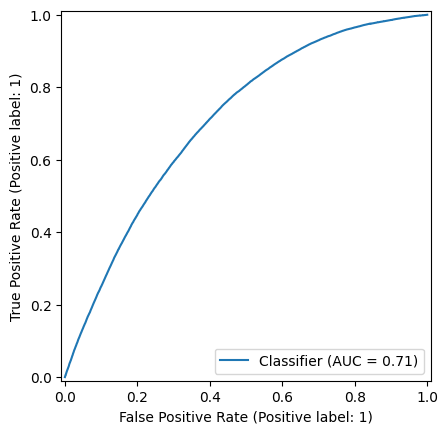

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20)

TP_FAIXA_ETARIA    0.282614
TP_ST_CONCLUSAO    0.131654
IN_TREINEIRO       0.073316
TP_ESCOLA          0.066066
TP_ESTADO_CIVIL    0.034950
Q010_A             0.029570
Q008_B             0.022893
Q004_D             0.018951
Q024_A             0.018662
Q005               0.018117
Q003_D             0.017220
Q002_B             0.016173
Q009_B             0.015883
Q002_G             0.013888
Q013_A             0.009120
Q018_B             0.009059
Q002_F             0.008502
Q002_E             0.007923
Q001_B             0.007902
Q022_B             0.007452
dtype: float64